# Salary Prediction Model

This notebook trains two regression models for predicting vacancy salary from structural features: country, remote flag, and technical skills. The target is the midpoint of `salary_min` and `salary_max`.

## Section 1 — Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "4_ml" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw_samples" / "jobs_2026_05_18.ndjson"
DASHBOARD_DIR = PROJECT_ROOT / "dashboards"
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")

Project root: /mnt/data/proj/bigData-it-market-analysis-main
Data path: /mnt/data/proj/bigData-it-market-analysis-main/data/raw_samples/jobs_2026_05_18.ndjson


## Section 2 — Load data

In [2]:
df_raw = pd.read_json(DATA_PATH, lines=True)
print(df_raw.shape)
df_raw.head()

(519, 11)


job_title,company,location,salary_min,salary_max,currency,remote,skills,description,source,collected_at
Senior Software Engineer - Java,Ocho,"Belfast, Northern Ireland",72626.12,72626.12,USD,True,"[Java, Microservices]","Senior Software Engineer Java, Microservices | Belfast (Hybrid) Location: Belfast Type: Permanent About the Opportunity: Join a highly collaborative backend team building core services that power a global content platform. This role focuses on designing and delivering scalable microservices in a cloud-native environment. What Youll Be Doing: Design, build, and maintain backend services and APIs Work on modernising monolith systems into microservices Write high-quality, test-driven code using TD…",Adzuna,2026-05-18
.NET Developer,Noir,"London, UK",70000.00,90000.00,USD,False,"[JavaScript, C#, Azure]",".NET Developer (Tech stack: .NET Developer, .NET 10.0, ASP.NET Core, C# 14, Azure DevOps, Agile, Blazor, JavaScript, React, Multithreading, RESTful, ML.NET, Azure AI, Programmer, Full Stack Engineer, Architect, .NET Developer)In just over 5 years our client has established themselves as the world's leading internet subscription service for enjoying films and TV programmes. They currently have over 15 million streaming members across the UK, Europe and North America and have plans to double in s…",Adzuna,2026-05-18
Senior Software Engineer,Matched Group,"Manchester, Greater Manchester",50000.00,60000.00,USD,False,"[Python, Ruby, AWS]","Senior Software Engineer Why? Lead a Greenfield web and mobile project Tech - Python, Ruby on Rails, React, Next, React Native, AWS We’re looking for a Senior Software Engineer who wants more than just an average dev job. You'll own features end-to-end, working closely with product owners, shaping architecture, and mentoring others while working with a modern, cloud-native stack. Great engineering is a team sport. Beyond strong technical skills, we’re looking for someone who communicates openly…",Adzuna,2026-05-18
Senior Java/Python Developer,Hays Specialist Recruitment Limited,"London, UK",182000.00,208000.00,USD,False,"[Python, Java, AWS, Terraform]","I am currently working with a Tier 1 Investment Bank who are actively seeking multiple Senior Software Developers who are proficient in both Java and Python. What you'll need to succeed : Extensive hands-on development with both Java and Python Strong financial services background, ideally within investment banking Strong cloud experience, ideally with AWS, ECS, and EKS Good knowledge of a range of databases, including Postgres Strong Terraform experience What you'll get in return : Initial 12-…",Adzuna,2026-05-18
Technical Lead - TypeScript / Node.js,Adria Solutions,"Manchester, Greater Manchester",60000.00,80000.00,USD,False,"[TypeScript, Node.js]","Technical Lead - TypeScript / Node.js As a Technical Lead, you’ll work directly with the founder to shape the technical vision and execution of a high-growth startup backed by a larger, established group. You’ll lead a talented engineering squad, drive architectural decisions, and deliver scalable backend systems that support thousands of users-all while influencing the strategic direction of the product. This is a hands-on leadership role where you’ll combine deep technical expertise with ment…",Adzuna,2026-05-18


## Section 3 — Feature engineering

In [3]:
df = df_raw.copy()

# Target: midpoint salary. If one boundary is missing, pandas uses the available value.
df["salary"] = df[["salary_min", "salary_max"]].mean(axis=1, skipna=True)
df = df.dropna(subset=["salary"]).copy()

# Remove unrealistic salaries / data-entry errors.
df = df[(df["salary"] >= 10_000) & (df["salary"] <= 500_000)].copy()

# Country: last token after comma, then keep top 15 countries and group the rest as Other.
df["country"] = (
    df["location"]
    .fillna("Unknown")
    .astype(str)
    .str.split(",")
    .str[-1]
    .str.strip()
    .replace("", "Unknown")
)
top_countries = df["country"].value_counts().head(15).index
df["country_grouped"] = np.where(df["country"].isin(top_countries), df["country"], "Other")

# Remote flag as 0/1.
df["remote_int"] = df["remote"].fillna(False).astype(bool).astype(int)

# Skills: multi-hot encode the skills array.
skill_dummies = df["skills"].explode().dropna().astype(str).str.strip()
skill_dummies = skill_dummies[skill_dummies != ""]
skill_matrix = pd.crosstab(skill_dummies.index, skill_dummies)
skill_matrix = skill_matrix.reindex(df.index, fill_value=0)
skill_matrix.columns = [f"skill_{column}" for column in skill_matrix.columns]

country_matrix = pd.get_dummies(df["country_grouped"], prefix="country", dtype=int)
remote_matrix = df[["remote_int"]]

X = pd.concat([remote_matrix, country_matrix, skill_matrix], axis=1)
y = df["salary"]

print("Rows after filtering:", len(df))
print("Feature matrix shape:", X.shape)
print("Target mean salary:", round(y.mean(), 2))
X.head()

Rows after filtering: 169
Feature matrix shape: (169, 82)
Target mean salary: 174609.13


## Section 4 — Train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

Train rows: 135
Test rows: 34


## Section 5 — Models

In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Models trained successfully")

Models trained successfully


## Section 6 — Metrics

In [6]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

metrics_df = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, lr_pred),
    evaluate_model("Random Forest", y_test, rf_pred),
])

metrics_df[["MAE", "RMSE"]] = metrics_df[["MAE", "RMSE"]].round(2)
metrics_df["R2"] = metrics_df["R2"].round(4)
metrics_df

model,MAE,RMSE,R2
Linear Regression,176200.42,250882.19,-2.9130
Random Forest,97120.73,120085.20,0.1035


## Section 7 — Visualization

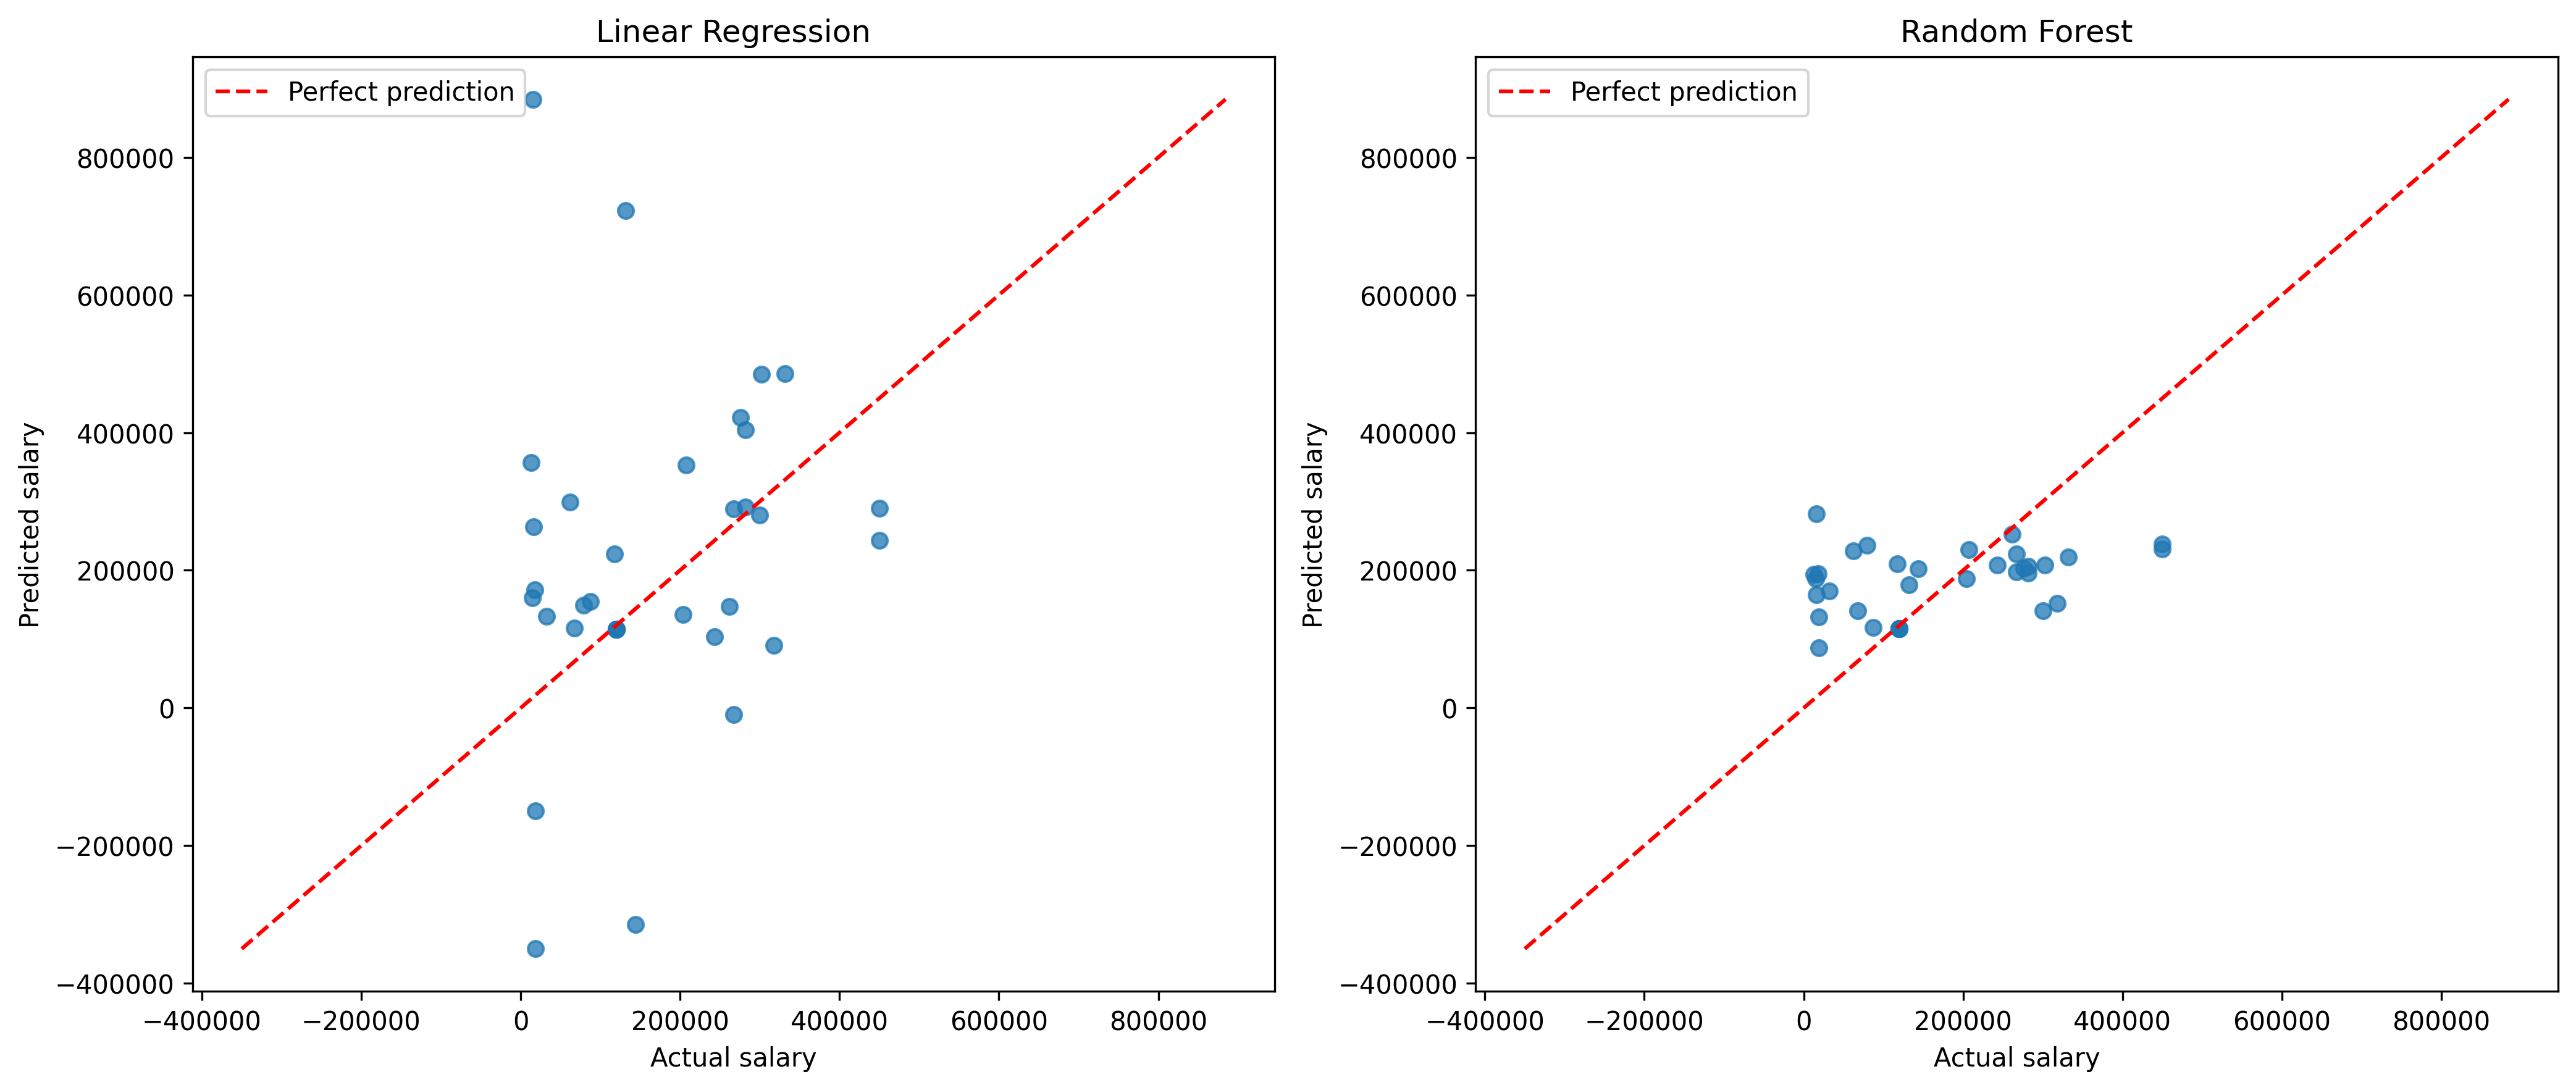

Saved: /mnt/data/proj/bigData-it-market-analysis-main/dashboards/ml_predicted_vs_actual.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plots = [
    ("Linear Regression", lr_pred, axes[0]),
    ("Random Forest", rf_pred, axes[1]),
]

min_salary = min(y_test.min(), lr_pred.min(), rf_pred.min())
max_salary = max(y_test.max(), lr_pred.max(), rf_pred.max())

for title, predictions, ax in plots:
    ax.scatter(y_test, predictions, alpha=0.75)
    ax.plot([min_salary, max_salary], [min_salary, max_salary], color="red", linestyle="--", label="Perfect prediction")
    ax.set_title(title)
    ax.set_xlabel("Actual salary")
    ax.set_ylabel("Predicted salary")
    ax.legend()

plt.tight_layout()
predicted_vs_actual_path = DASHBOARD_DIR / "ml_predicted_vs_actual.png"
plt.savefig(predicted_vs_actual_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {predicted_vs_actual_path}")

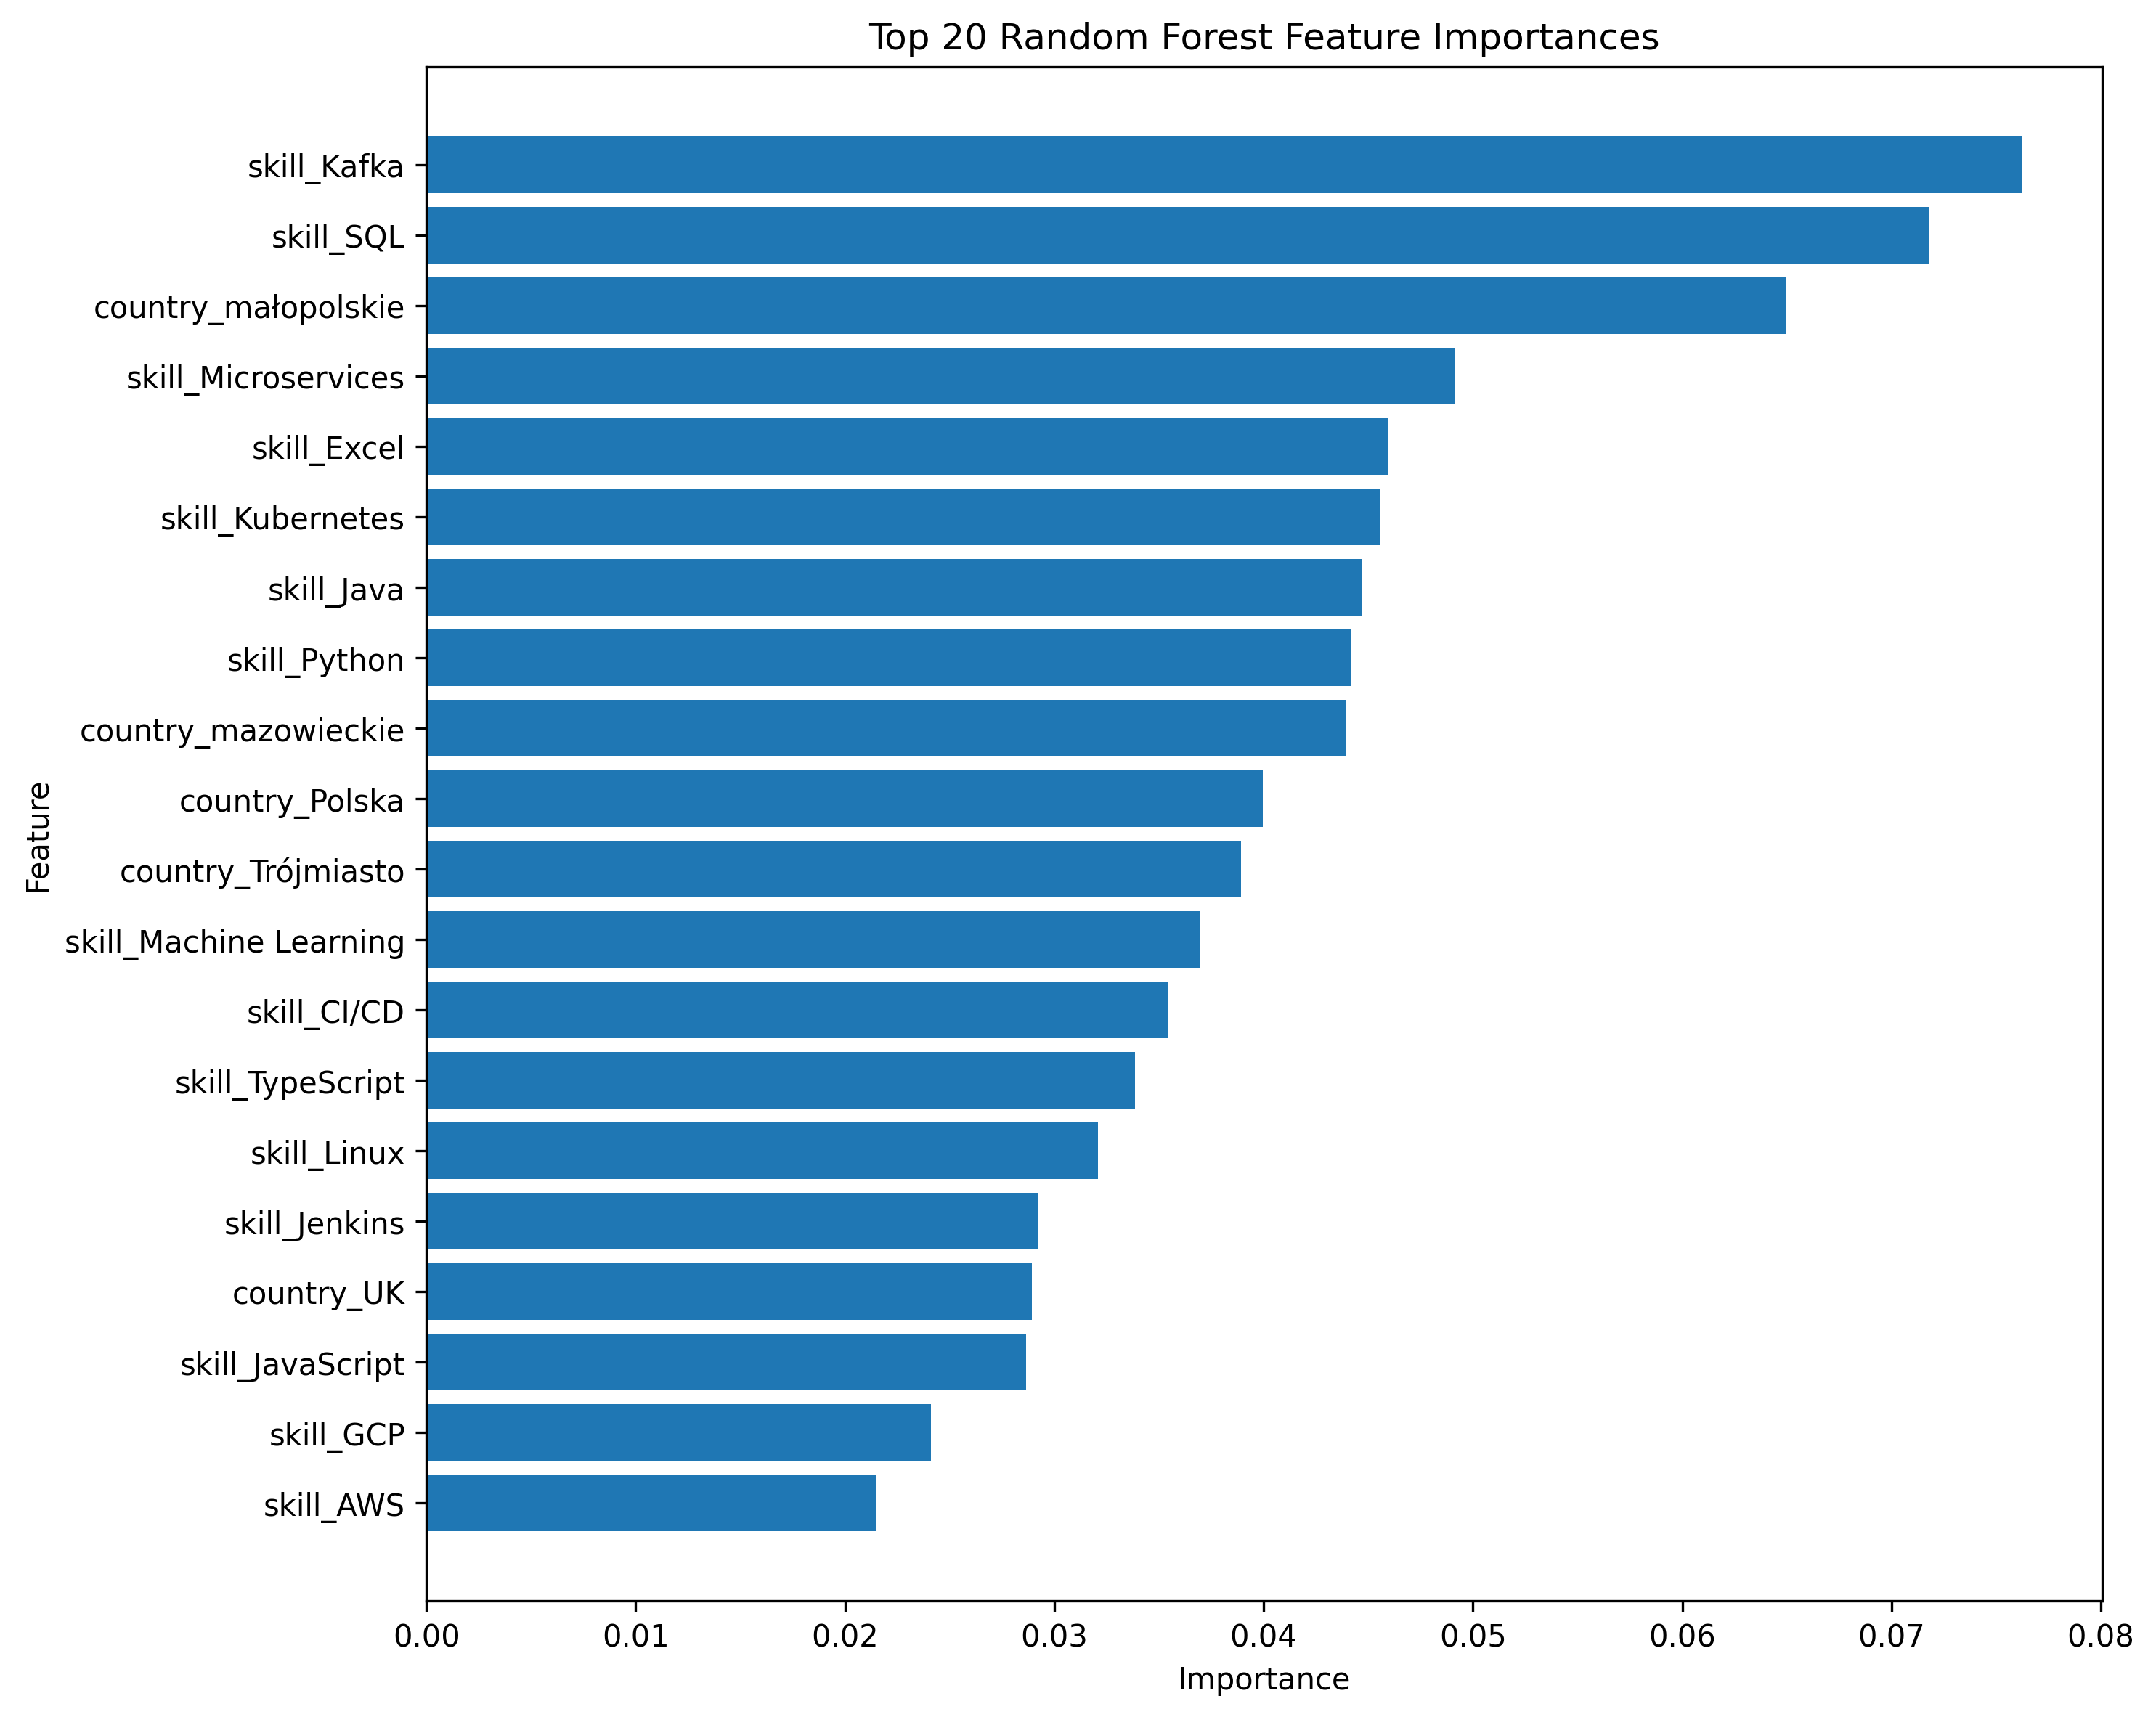

Saved: /mnt/data/proj/bigData-it-market-analysis-main/dashboards/ml_feature_importance.png


feature,importance
skill_Kafka,0.076253
skill_SQL,0.071777
country_małopolskie,0.064972
skill_Microservices,0.049118
skill_Excel,0.045928
skill_Kubernetes,0.045577
skill_Java,0.044722
skill_Python,0.044153
country_mazowieckie,0.043929
country_Polska,0.039947


In [8]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance["feature"][::-1], feature_importance["importance"][::-1])
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

feature_importance_path = DASHBOARD_DIR / "ml_feature_importance.png"
plt.savefig(feature_importance_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {feature_importance_path}")
feature_importance

## Section 8 — Markdown summary

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | 176,200.42 | 250,882.19 | -2.913 |
| Random Forest | 97,120.73 | 120,085.20 | 0.104 |

The dataset is relatively small after salary filtering, so the model should be treated as an analytical extension rather than a production-grade salary predictor.

Linear Regression works as a baseline, but it performs poorly because the feature matrix is sparse and the sample size is small. Random Forest performs better because it can capture non-linear interactions between skills, location, and remote status.

The most important Random Forest features in this run are mostly technical skills and country indicators. Kafka, SQL, Microservices, Kubernetes, Java, Python, and Polish regional/country features are among the strongest signals. To improve the model, the project would need a larger dataset, better currency normalization, seniority extraction, and more reliable location parsing.